In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter
import geopandas as gpd
from matplotlib.colors import LogNorm


In [2]:
otu_rpo = pd.read_csv('../data_processed/otu_rpo.csv', index_col=0)
sample_table = pd.read_csv('../data_processed/sample_table.csv', index_col=0)
tax = pd.read_csv('../data_processed/tax.csv', index_col=0)
print('OTU:', otu_rpo.shape, '| Sample:', sample_table.shape)

OTU: (13199, 1513) | Sample: (1513, 425)


In [3]:
keys_pattern = r"(cbb_1|rtca_1|wl_1|hp_1|hphb_1|dchb_1)"
name_map = {"cbb_1": "CBB", "rtca_1": "rTCA", "wl_1": "WL",
            "hp_1": "3HP", "hphb_1": "HPHB", "dchb_1": "DC/HB"}

matched = (tax["key_genes"]
           .str.extract(keys_pattern, expand=False)
           .map(name_map)
           .dropna())

cf_markers = matched.reset_index()
cf_markers.columns = ["KO", "Pathway"]
pathway_order = ["CBB", "rTCA", "WL", "3HP", "HPHB", "DC/HB"]
print(f"Markers: {len(cf_markers)} KOs across {cf_markers['Pathway'].nunique()} pathways")
print(cf_markers["Pathway"].value_counts())

Markers: 29 KOs across 6 pathways
Pathway
rTCA     7
WL       7
3HP      6
HPHB     5
CBB      3
DC/HB    1
Name: count, dtype: int64


In [4]:
def compute_cfpi(otu_df, markers_df, pathway_order=None, pathway_summary='mean'):
    markers_present = markers_df[markers_df['KO'].isin(otu_df.index)].copy()
    pathway_scores = {}
    for pw in markers_present['Pathway'].unique():
        kos = markers_present[markers_present['Pathway'] == pw]['KO'].tolist()
        available = [ko for ko in kos if ko in otu_df.index]
        if pathway_summary == 'mean':
            pathway_scores[pw] = otu_df.loc[available].mean(axis=0)
        else:
            pathway_scores[pw] = otu_df.loc[available].sum(axis=0)
    pathway_df = pd.DataFrame(pathway_scores)
    if pathway_order:
        for pw in pathway_order:
            if pw not in pathway_df.columns:
                pathway_df[pw] = 0
        existing = [p for p in pathway_order if p in pathway_df.columns]
        other = [c for c in pathway_df.columns if c not in existing]
        pathway_df = pathway_df[existing + other]
    pathway_df['CFPI_total'] = pathway_df.sum(axis=1)
    for col in pathway_df.columns[:-1]:
        pathway_df['frac_' + col] = pathway_df[col] / pathway_df['CFPI_total']
    return pathway_df

res = compute_cfpi(otu_rpo, cf_markers, pathway_order=pathway_order)
res.index.name = 'SampleID'
print('CFPI:', res.shape)

CFPI: (1513, 13)


In [5]:
cfpi_full = res.join(sample_table, how='inner')
print('Merged:', len(cfpi_full))
cfpi_sub = cfpi_full[cfpi_full['sample_group'] == 'subsurface_sample'].copy()
print('Subsurface:', len(cfpi_sub))

Merged: 1513
Subsurface: 412


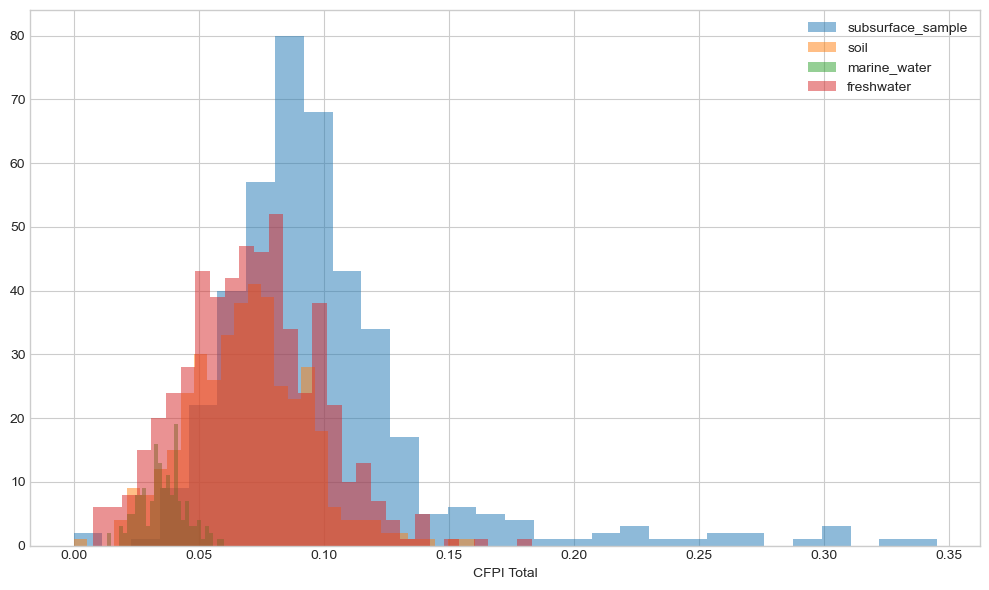

In [6]:
fig, ax = plt.subplots(figsize=(10,6))
for env in cfpi_full['sample_group'].unique():
    data = cfpi_full[cfpi_full['sample_group'] == env]['CFPI_total'].dropna()
    if len(data) > 0:
        ax.hist(data, bins=30, alpha=0.5, label=env)
ax.set_xlabel('CFPI Total')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
numeric_cols = cfpi_sub.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['CFPI_total','latitude','longitude']
env_vars = [c for c in numeric_cols if c not in exclude]
cor_results = []
for var in env_vars:
    valid = cfpi_sub[[var,'CFPI_total']].dropna()
    if len(valid) >= 10:
        rho, p = stats.spearmanr(valid[var], valid['CFPI_total'])
        cor_results.append({'variable': var, 'rho': rho, 'p': p})
cor_df = pd.DataFrame(cor_results)
_, p_adj, _, _ = multipletests(cor_df['p'], method='fdr_bh')
cor_df['p_adj'] = p_adj
cor_df = cor_df.sort_values('rho', key=abs, ascending=False)
filtered = cor_df[(abs(cor_df['rho']) >= 0.25) & (cor_df['p_adj'] < 0.01)]
print(filtered.head(15).to_string(index=False))

      variable       rho             p         p_adj
mean_CFP_key_1  0.928515 1.629233e-178 3.926450e-176
    mean_cbb_1  0.657715  2.113253e-52  1.827686e-50
           CBB  0.657560  2.275127e-52  1.827686e-50
          rTCA  0.524552  1.671490e-30  8.180498e-29
   mean_rtca_1  0.524500  1.697199e-30  8.180498e-29
          ag_s -0.492005  3.299899e-04  3.787027e-03
          ti_d -0.468148  4.374069e-05  5.270754e-04
            WL  0.432159  3.546698e-20  1.232196e-18
     mean_wl_1  0.432118  3.578993e-20  1.232196e-18
          temp  0.394402  4.852806e-16  1.461908e-14
             w  0.372676  6.532990e-07  1.049634e-05
      he4_ne20  0.370153  1.082943e-07  2.609893e-06
             v -0.367541  2.653886e-07  4.919897e-06
             X  0.349644  8.732822e-07  1.315381e-05
      frac_CBB -0.318085  4.308259e-11  1.153656e-09


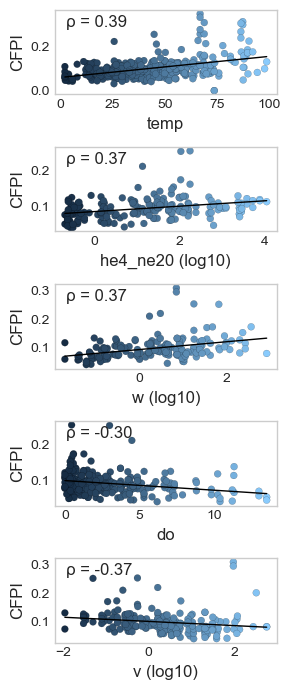

In [8]:


vars_to_check = ['temp','he4_ne20','w','do','v']
log_vars = ['he4_ne20','w','v']

# custom colormap
my_cmap = LinearSegmentedColormap.from_list(
    "custom_blue",
    ["#152b43ff", "#89cbfdff"]
)
valid_vars = [var for var in vars_to_check if var in cfpi_sub.columns]

n = len(valid_vars)
fig, axes = plt.subplots(n, 1, figsize=(3, 1.4*n))

if n == 1:
    axes = [axes]

for ax, var in zip(axes, valid_vars):
    sub = cfpi_sub[[var, 'CFPI_total']].dropna().copy()
    
    if len(sub) >= 10:
        
        x = sub[var].astype(float)
        y = sub['CFPI_total'].astype(float)
        
        # log transform if needed
        if var in log_vars:
            mask = x > 0
            x = np.log10(x[mask])
            y = y[mask.values]
        
        x = np.array(x)
        y = np.array(y)
        
        ax.scatter(
            x, y,
            c=x,
            cmap=my_cmap,
            edgecolor='black',
            linewidth=0.09,
            s=25
        )
        
        # regression line
        coef = np.polyfit(x, y, 1)
        poly = np.poly1d(coef)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, poly(x_line), color='black', linewidth=1)
        
        rho, _ = stats.spearmanr(x, y)
        
        ax.grid(False)
        
        ax.text(
            0.05, 0.8,
            f"ρ = {rho:.2f}",
            fontsize= 12,
            transform=ax.transAxes
        )
        
        ax.set_xlabel(f"{var} (log10)" if var in log_vars else var, fontsize=12)
        ax.set_ylabel(r"CFPI", fontsize=12)

plt.tight_layout()
plt.savefig("../outputs/CFPItot_vs_env.svg", bbox_inches='tight', transparent=True)

plt.show()

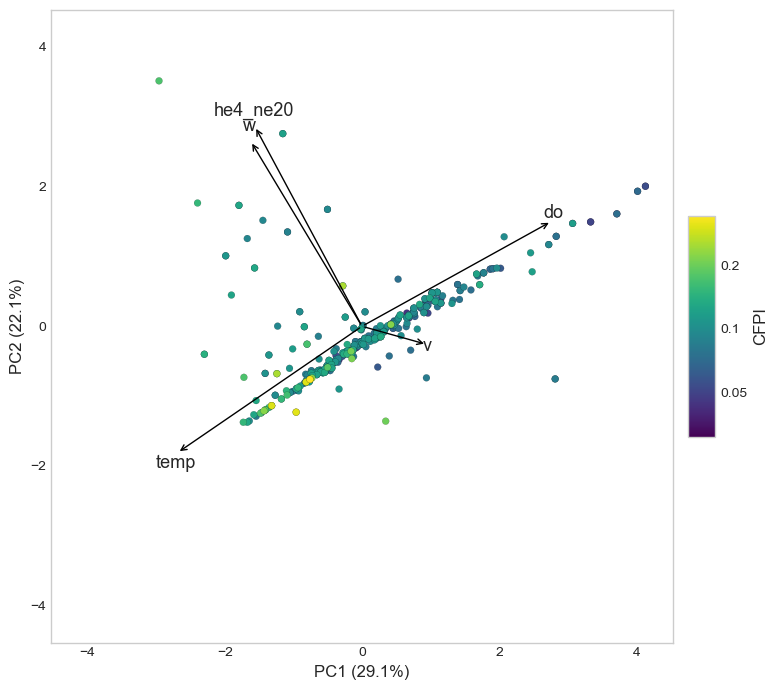

In [9]:
vars_core = ['v', 'w', 'temp', 'he4_ne20', 'do']

df = cfpi_sub[vars_core + ['CFPI_total']].copy()

# fill missing values for PCA variables
for col in vars_core:
    df[col] = df[col].fillna(df[col].median())

df = df.dropna(subset=vars_core + ['CFPI_total'])

X = df[vars_core].values
X = X / X.std(axis=0)

pca = PCA(n_components=2)
scores = pca.fit_transform(X)
loadings = pca.components_
var_exp = pca.explained_variance_ratio_

cfpi = df['CFPI_total'].values

lim = np.percentile(np.abs(scores), 97) * 1.6
arrow_r = lim * 0.72

load_norms = np.sqrt(loadings[0]**2 + loadings[1]**2)
scale = arrow_r / load_norms.max()

fig, ax = plt.subplots(figsize=(8.2, 7))

# sort by CFPI so high values are plotted last (on top)
order = np.argsort(cfpi)

sc = ax.scatter(
    scores[order, 0],
    scores[order, 1],
    c=cfpi[order],
    cmap="viridis",
    norm=LogNorm(vmin=cfpi[cfpi > 0].min(), vmax=cfpi.max()),
    s=25,
    alpha=1,
    edgecolors="black",
    linewidths=0.09
)

texts = []

for i, var in enumerate(vars_core):
    lx = loadings[0, i] * scale
    ly = loadings[1, i] * scale

    ax.annotate(
        "",
        xy=(lx, ly),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", lw=1)
    )

    t = ax.text(
        lx * 1.01,
        ly * 1.08,
        var,
        fontsize=13,
        ha="center",
        va="center"
    )
    texts.append(t)


ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize= 12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize= 12)

#ax.set_title(f"PCA of environmental variables (n={len(df)})")

ax.grid(False)

cbar = plt.colorbar(sc, ax=ax, shrink=0.35, pad=0.02, aspect=8)
cbar.set_ticks([0.05, 0.1, 0.2])
cbar.formatter = FuncFormatter(lambda x, pos: f"{x:g}")
cbar.update_ticks()
cbar.set_label(r"CFPI", fontsize= 12)





plt.tight_layout()
plt.savefig("../outputs/PCA_env_variables_CFPItot.svg", bbox_inches='tight', transparent=True)

plt.show()

In [10]:
hf_db = pd.read_csv('../data/reference/HFgrid14.csv', sep=';')
hf_db = hf_db.rename(columns={'longiyude': 'longitude'})
print('Heatflow:', hf_db.shape)

Heatflow: (259200, 5)


In [11]:
T_limit, T_surface, K_rock = 135, 15, 2.5
hf = hf_db[hf_db['HF_pred'].notna() & (hf_db['HF_pred'] > 0)].copy()
hf['z135_m'] = ((T_limit - T_surface) * K_rock) / (hf['HF_pred'] / 1000)
print('z135 (uncapped):', hf['z135_m'].describe())

z135 (uncapped): count    259193.000000
mean       4501.513428
std        1728.891090
min         100.759052
25%        3694.581281
50%        4552.352049
75%        5263.157895
max      428571.428571
Name: z135_m, dtype: float64


In [12]:
# Same 50m shapefile as R's ne_countries(scale="medium")
world = gpd.read_file("../data/reference/naturalearth/ne_50m_admin_0_countries.shp")
land = world.geometry.union_all()

hf_gdf = gpd.GeoDataFrame(
    hf.reset_index(drop=True),
    geometry=gpd.points_from_xy(hf['longitude'], hf['latitude']),
    crs='EPSG:4326'
)
land_gdf = gpd.GeoDataFrame(geometry=[land], crs='EPSG:4326')
joined = gpd.sjoin(hf_gdf[['geometry']], land_gdf, how='left', predicate='within')
hf['domain'] = np.where(joined['index_right'].notna(), 'continental', 'oceanic')
print(hf['domain'].value_counts())

domain
oceanic        173494
continental     85699
Name: count, dtype: int64


In [13]:
hf['z_cap'] = np.where(hf['domain'] == 'oceanic', 3000, 8000)
hf['z135_m'] = hf[['z135_m', 'z_cap']].min(axis=1)
print('z135 (capped):', hf['z135_m'].describe())

z135 (capped): count    259193.000000
mean       3544.066322
std        1228.727980
min         100.759052
25%        3000.000000
50%        3000.000000
75%        4172.461752
max        8000.000000
Name: z135_m, dtype: float64


In [14]:
R = 6371000
dx = dy = 0.5
hf['cell_area_m2'] = (dx * np.pi / 180) * R * np.cos(hf['latitude'] * np.pi / 180) * (dy * np.pi / 180) * R
hf['porosity'] = np.where(hf['domain'] == 'continental', 0.05, 0.03)
hf['porosity_low'] = np.where(hf['domain'] == 'continental', 0.03, 0.01)
hf['porosity_high'] = np.where(hf['domain'] == 'continental', 0.08, 0.05)
hf['V_water_km3'] = hf['cell_area_m2'] * hf['z135_m'] * hf['porosity'] / 1e9
hf['V_water_low_km3'] = hf['cell_area_m2'] * hf['z135_m'] * hf['porosity_low'] / 1e9
hf['V_water_high_km3'] = hf['cell_area_m2'] * hf['z135_m'] * hf['porosity_high'] / 1e9
volumes = hf.groupby('domain')[['V_water_km3','V_water_low_km3','V_water_high_km3']].sum().reset_index()
print(volumes)

        domain   V_water_km3  V_water_low_km3  V_water_high_km3
0  continental  3.643932e+07     2.186359e+07      5.830292e+07
1      oceanic  3.098985e+07     1.032995e+07      5.164975e+07


In [15]:
low_anchor, mid_anchor, high_anchor = 0.0095, 0.043, 1.49
if 'sample_type' in cfpi_sub.columns:
    fluid_only = cfpi_sub[cfpi_sub['sample_type'] == 'fluid']
else:
    fluid_only = cfpi_sub
q05, q50, q95 = fluid_only['CFPI_total'].quantile([0.05, 0.50, 0.95])
log_low = np.log10(low_anchor)
log_mid = np.log10(mid_anchor)
log_high = np.log10(high_anchor)
print('Quantiles:', q05, q50, q95)

Quantiles: 0.05170461891869706 0.08515084448795152 0.13639499389499374


In [16]:
def piecewise_interp(CFPI, q05, q50, q95, ll, lm, lh):
    lr = np.where(CFPI <= q05, ll,
        np.where((CFPI > q05) & (CFPI <= q50),
            ll + (CFPI - q05) / (q50 - q05) * (lm - ll),
            np.where((CFPI > q50) & (CFPI <= q95),
                lm + (CFPI - q50) / (q95 - q50) * (lh - lm), lh)))
    return 10 ** lr
df_fluid = fluid_only.copy()
df_fluid['rate_ug_L_d'] = piecewise_interp(df_fluid['CFPI_total'].values, q05, q50, q95, log_low, log_mid, log_high)
print(df_fluid['rate_ug_L_d'].describe())

count    212.000000
mean       0.198890
std        0.368748
min        0.009500
25%        0.023009
50%        0.043051
75%        0.140621
max        1.490000
Name: rate_ug_L_d, dtype: float64


In [17]:
global_vol = pd.DataFrame({'domain': ['global'], 'V_water_km3': [volumes['V_water_km3'].sum()], 'V_water_low_km3': [volumes['V_water_low_km3'].sum()], 'V_water_high_km3': [volumes['V_water_high_km3'].sum()]})
volumes_all = pd.concat([volumes, global_vol], ignore_index=True)
rate_mean = df_fluid['rate_ug_L_d'].mean()
rate_q25 = df_fluid['rate_ug_L_d'].quantile(0.25)
rate_q75 = df_fluid['rate_ug_L_d'].quantile(0.75)
fluxes = []
for _, row in volumes_all.iterrows():
    V = row['V_water_km3']
    V_h = row['V_water_high_km3']
    fluxes.append({'domain': row['domain'], 'low': rate_q25 * V * 1e12 * 365 / 1e21, 'mid': rate_mean * V * 1e12 * 365 / 1e21, 'high': rate_q75 * V_h * 1e12 * 365 / 1e21})
fluxes_df = pd.DataFrame(fluxes)
print(fluxes_df.to_string(index=False))

     domain      low      mid     high
continental 0.306024 2.645311 2.992487
    oceanic 0.260259 2.249707 2.651003
     global 0.566283 4.895017 5.643490


In [ ]:
cfpi_full.to_csv('../outputs/cfpi_by_sample.csv')
df_fluid.to_csv('../outputs/fluid_cfpi.csv')
volumes_all.to_csv('../outputs/subsurface_volumes.csv', index=False)
fluxes_df.to_csv('../outputs/carbon_fluxes.csv', index=False)